# Mouvement Brownien

La **simulation exacte** d'un processus $(X_t)_{t \in [0,T]}$ consiste en la simulation du vecteur $(X_{t_0}, \dots, X_{t_N})$ pour des instants $0 = t_0 \le \cdots \le t_N = T$. Souvent on découpe l'intervalle $[0, T]$ en $N$ intervalles de même longueur c'est à dire en considérant $N+1$ points $t_k$ définis par 
\begin{equation*}
    t_k = k \frac{T}{N} \quad \forall k \in \{0,\dots,N\}.
\end{equation*}

On rappelle deux définitions d'un mouvement Brownien standard $(B_t)_{t \ge 0}$.

1. $(B_t)_{t \ge 0}$ est un PAIS (Processus à Accroissements Indépendants et Stationnaires) continu, nul en 0, tel que $B_t \sim \mathcal{N}(0,t)$.
2. $(B_t)_{t \ge 0}$ est un processus gaussien nul en 0 de covariance $\mathrm{Cov}(B_s, B_t) = \mathbb{E}[B_s B_t] = s \wedge t$.

### Question: initialisation 

Ecrire mathématiquement l'algorithme de simulation de $(B_0, \dots, B_{t_N})$ en utilisant la définition 1. puis la défintion 2. et faire le lien.

0.13846169750224116
0.046746339765517606


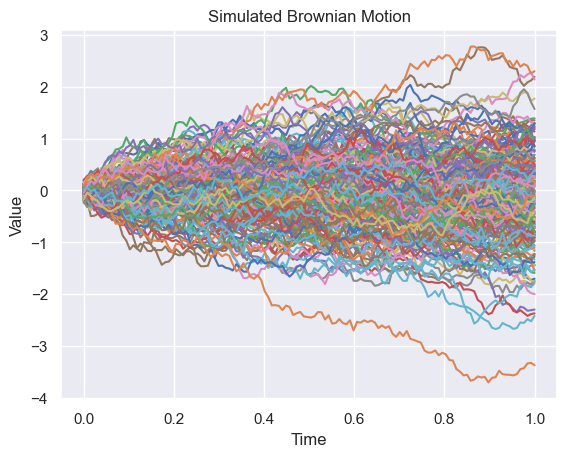

0.1383229731779783
0.0738131603552446


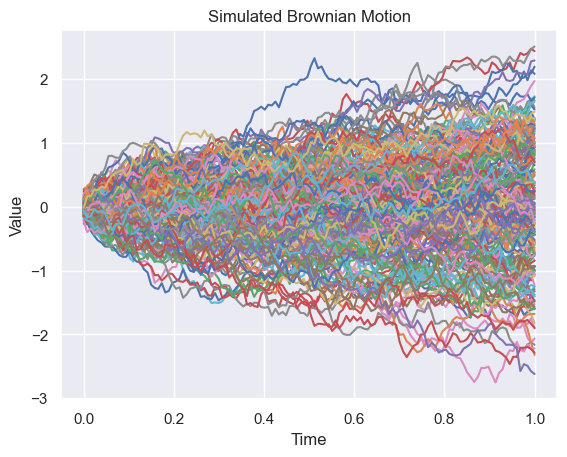

In [37]:
import numpy as np
import scipy.stats as sps
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
from numpy.random import default_rng, SeedSequence

# Définition 1 and simulation of a Brownian motion
sq = SeedSequence()
rng = default_rng(sq)
n_timesteps = 128
n_paths = 200
T = 1.0
dt = T / n_timesteps
increments = np.sqrt(dt) * rng.normal(size=(n_timesteps, n_paths))
brownian_motion = np.cumsum(increments, axis=0)


print(np.mean(brownian_motion[:, -1]))
print(np.var(brownian_motion[:, -1]))
plt.plot(np.linspace(0, T, n_timesteps), brownian_motion)
plt.title("Simulated Brownian Motion")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

# Définition 2 and simulation of a Brownian motion
cov_matrix = (np.fromfunction(lambda i, j: np.minimum(i, j), (n_timesteps, n_timesteps)) + 1)* dt

cholesky_decomp = np.linalg.cholesky(cov_matrix)
brownian_motion_2 = np.dot(cholesky_decomp, rng.normal(size=(n_timesteps, n_paths)))
print(np.mean(brownian_motion_2[:, -1]))
print(np.var(brownian_motion_2[:, -1]))

plt.plot(np.linspace(0, T, n_timesteps), brownian_motion_2)
plt.title("Simulated Brownian Motion")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

## Marche aléatoire

D'après la définition 1. on simule d'abord les accroissements indépendants $B_{t_{k+1}} - B_{t_k} \sim \mathcal{N}(0, t_{k+1}-t_{k})$ puis on reconstruit $B_{t_k} = \sum_{j=0}^{k-1} (B_{t_{j+1}} - B_{t_j})$ (somme téléscopique).

A partir de $N$ gaussiennes indépendantes $(G_k)_{k=1,\dots,N}$ on construir le vecteur $(B_{t_1},\dots,B_{t_N})$ par la récurrence:
\begin{equation*}
    B_{t_{k+1}} = B_{t_k} + \sqrt{t_{k+1} - t_k} G_{k+1}
\end{equation*}

**Important:** si on veut simuler $M$ trajectoires il faut donc $M \times N$ réalisations indépendantes de gaussiennes. En numpy il faut (si possible) tout simuler d'un bloc et mettre en mémoire les $M \times N$ données.

### Question: simulation par marche aléatoire

Ecrire une fonction de prototype:
```
def brownian_1d(n_times: int, n_paths: int, 
                final_time: float=1.0, 
                increments: bool=False, 
                random_state: np.random.Generator=rng)
```
qui simule `n_paths` trajectoires de $(B_t)_{t \in [0,T]}$ aux instants $t_k = k T/n$ où $n$ est donné par l'argument `n_times` et $T$ est `final_time`. L'argument optionnel `increments` est un booléen qui indique si on renvoie le vecteur du Brownien $(B_0, B_{t_1}, \dots, B_{t_n})$ ou ses accroissements $(B_{t_1}-B_0, \dots, B_{t_n}-B_{t_{n-1}})$.

### Question: représentation graphique 

Tester votre fonction en traçant $M=200$ trajectoires du mouvement Brownien discrétisé avec $N=128$ pas de temps. 

## Processus Gaussien 

D'après la définition 2. on a  
\begin{equation*}
\begin{pmatrix}
B_{t_1} \\ \vdots \\ B_{t_N}
\end{pmatrix} 
\sim \mathcal{N} \big(0, \Sigma \big), \quad 
\text{avec} \quad 
\Sigma = \begin{pmatrix}
t_1 & t_1 & \cdots & t_1 & t_1 \\
t_1 & t_2 & \cdots & t_2 & t_2 \\
\vdots & \vdots & \ddots & \ddots & \vdots \\
t_1 & t_2 & \cdots & t_{N-1} & t_{N-1} \\
t_1 & t_2 & \cdots & t_{N-1} & t_N 
\end{pmatrix}.
\end{equation*}

La matrice $\Sigma$ est symmétrique définie positive donc par la décomposition de Cholesky il existe une matrice triangulaire inférieure $L$ telle que $L L^\top = \Sigma$. Ainsi le vecteur $(B_{t_1}, \dots, B_{t_N})$ a même loi que $L G$ où $G = (G_1, \dots, G_n) \sim \mathcal{N}(0, \operatorname{Id}_N)$.

### Question: simulation en tant que processus Gaussien 

Ecrire le code correspondant, tracer des trajectoires et les comparer à la première approche.

Il est possible de construire directement la matrice triangulaire inférieure $L$.

## Construction récursive
La construction trajectorielle de Paul Lévy permet aussi de simuler le mouvement Brownien: il s'agit d'affiner la trajectoire, itération après itération, en suivant le découpage dyadique de $[0,1]$.

La propriété principale est la suivante $\forall l < t < r$, $\forall x,y \in \mathbb{R}$
\begin{equation*}
    B_t \big\lvert B_l = x, B_r = y \sim \mathcal{N}\left(\frac{r-t}{r-l} x + \frac{t-l}{r-l} y, \frac{(r-t)(t-l)}{r-l} \right),
\end{equation*}
en particulier si on considère $r - l = h$ et $r - t = t - l = \frac{h}{2}$ alors $\forall x,y \in \mathbb{R}$
\begin{equation*}
    B_{l + \frac{h}{2}} \big\lvert B_l = x, B_{l + h} = y \sim \mathcal{N}\left( \frac{x+y}{2}, \frac{h}{4} \right)
\end{equation*}

### Question: démonstration

Démontrer cette propriété sur la loi conditionnelle du Brownien en un instant $t$ sachant $\{B_l=x, B_r=y\}$, $l < t < r$.

### Question: simulation récursive 

Ecrire un code pour simuler des trajectoires aux instants $t_k$ de la forme $t_k = k 2^{-n}$, c'est à dire $N = 2^n$ et $T=1$. La construction se fera en raffinant les trajectoires, on fera varier $n=0,\dots,7$.

### Question: pont Brownien

Le pont Brownien standard est défini comme le Brownien conditionné à revenir en 0 à l'instant terminal $T = 1$. En utilisant l'approche précédente, écrire un code de simulation de trajectoires du pont Brownien.

### Question: Brownien conditionné

De la même façon faire la simulation d'un Brownian conditionné tel que la loi terminale soit une uniforme sur les entiers $\{-2, -1, 0, 1,2,3,4\}

## Dimension $d \ge 2$

On considère d'abord un Brownien en dimension 2, $B = (B^1, B^2)$ de corrélation $\rho \in [-1,1]$, c'est à dire tel que $\operatorname{Corr}(B^1_t, B^2_t) = \rho$ (ou $\operatorname{Cov}(B^1_t, B^2_t) = \rho t$). On rappelle que $B$ se représente sous la forme 
\begin{equation*}
    \begin{cases}
    B^1_t &= W^1_t, \\
    B^2_t &= \rho W^1_t + \sqrt{1-\rho^2} W^2_t
    \end{cases}
\end{equation*}
où $W = (W^1, W^2)$ est un Brownien bidimensionnel dont les composantes sont indépendantes. 

### Question: simulation 2d

Ecrire une fonction `brownian_2d` similaire à `brownian_1d` avec un argument supplémentaire `correlation` pour le paramètre $\rho \in [-1,1]$.

In [72]:
def brownian_2d(n_timesteps, n_paths, T, rng, rho):
    dt = T / n_timesteps
    increments = np.sqrt(dt) * rng.normal(size=(n_timesteps, n_paths))
    brownian_motion_x = np.cumsum(increments, axis=0)

    dt = T / n_timesteps
    increments = np.sqrt(dt) * rng.normal(size=(n_timesteps, n_paths))
    brownian_motion_y = np.cumsum(increments, axis=0)
    brownian_motion_y = rho * brownian_motion_x + np.sqrt(1 - rho**2) * brownian_motion_y
    
    return brownian_motion_x, brownian_motion_y

### Question: visualisation 

Simuler 1 trajectoire du Brownien bidimensionnel et tracer les deux composantes spatiales en fonction du temps. Faites varier le paramètre $\rho$.

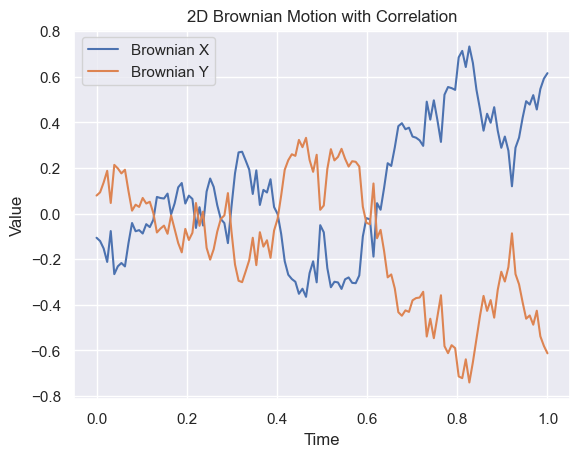

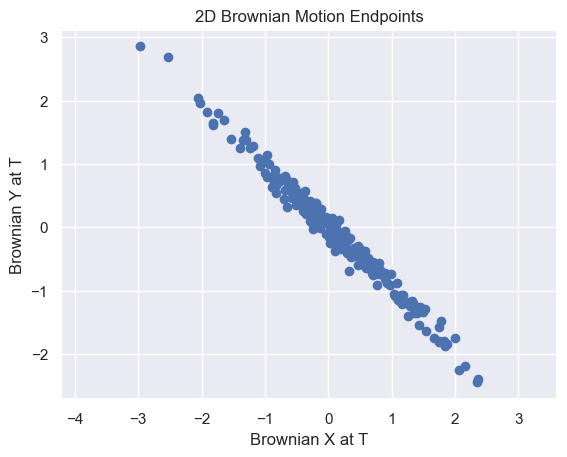

In [82]:
T = 1.0
n_timesteps = 128
rho = -0.99
n_paths = 200
brownian_x, brownian_y = brownian_2d(n_timesteps, n_paths, T, rng, rho)
plt.plot(np.linspace(0, T, n_timesteps), brownian_x[: , 0], label='Brownian X')
plt.plot(np.linspace(0, T, n_timesteps), brownian_y[: , 0], label='Brownian Y')
plt.title("2D Brownian Motion with Correlation")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()


plt.scatter(brownian_x[-1, :], brownian_y[-1, :])
plt.title("2D Brownian Motion Endpoints")   
plt.xlabel("Brownian X at T")
plt.ylabel("Brownian Y at T")
plt.axis('equal')
plt.show()

### Question: simulation cas $d \ge 2$

On se place maintenant en dimension $d \ge 2$ et on suppose que la matrice de corrélation entre les Browniens est donnée par $\Sigma$ (une matrice symmétrique définie positive avec des 1 sur la diagonale).

Ecrire une fonction `brownian_md` qui prend comme argument une matrice triangulaire inférieure $L$ (`correlations`) telle que $L L^\top = \Sigma$ et qui renvoie des réalisations du mouvement Brownien multidimensionnel.